 col1    col2  col3      col4     ...  col47   col48   col49   col50 
------ ------- ---- ------------- ... ------- ------- ------- -------
0.0207 0.15867  5.0  0.0908484459 ...     3.1   3.144   3.184   3.169
0.0207 0.15867  5.0  0.1029257253 ...   2.904    2.95   2.994   2.979
0.0207 0.15867  5.0  0.1196667179 ...   2.674   2.722   2.772   2.757
0.0207 0.15867  5.0  0.1208098754 ...   2.658   2.707   2.758   2.743
0.0207 0.15867  5.0  0.1298256516 ...   2.561   2.611   2.667   2.652
0.0207 0.15867  5.0  0.1407841742 ...   2.443   2.495   2.557   2.542
0.0207 0.15867  5.0  0.1476055831 ...   2.384   2.437   2.504   2.489
0.0207 0.15867  5.0  0.1696521044 ...   2.197   2.252   2.336    2.32
0.0207 0.15867  5.0  0.1825985014 ...   2.099   2.154   2.246   2.229
0.0207 0.15867  5.0  0.1965744495 ...   1.991   2.045   2.147   2.129
   ...     ...  ...           ... ...     ...     ...     ...     ...
0.0207 0.15867  7.0 18.5974731445 ... -10.719 -10.645 -10.501 -10.548
0.0207 0.15867  7.0 

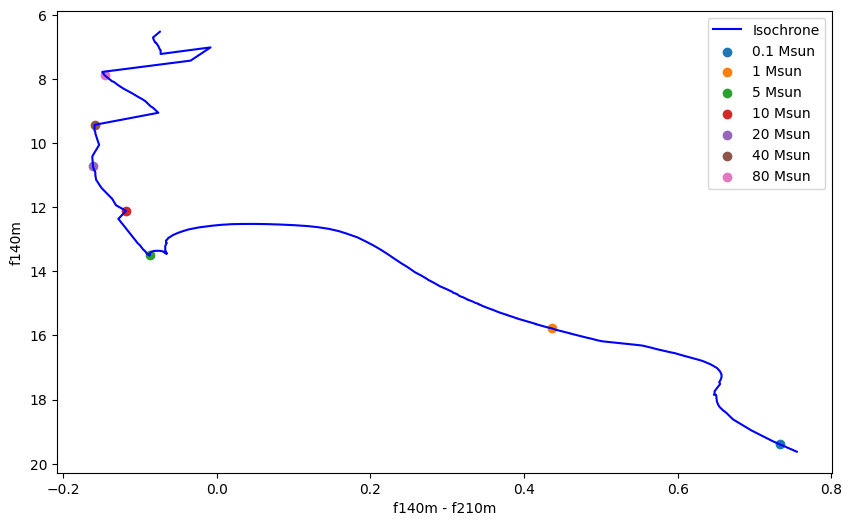

In [3]:
from astropy.table import Table
import crds
from sklearn.mixture import GaussianMixture
import itertools
import matplotlib.pyplot as plt
import numpy as np
import os
import astropy.units as u
from dust_extinction.averages import CT06_MWLoc
ext = CT06_MWLoc()
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
parsec_av0.pprint()
mass_av0 = parsec_av0['col6']

F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5

age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))

parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
}    

print(np.max(mass_av0[age_idx]))
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(111)
ax1.plot(parsec_mags['f140m'][age_idx]-parsec_mags['f210m'][age_idx], parsec_mags['f140m'][age_idx], color='blue', label='Isochrone')
for mass in [0.1, 1, 5, 10, 20, 40, 80]:
    idx_mass = np.argmin(np.abs(mass_av0[age_idx]-mass))
    ax1.scatter(parsec_mags['f140m'][age_idx][idx_mass]-parsec_mags['f210m'][age_idx][idx_mass], parsec_mags['f140m'][age_idx][idx_mass], label=f'{mass} Msun')
ax1.set_xlabel('f140m - f210m')
ax1.set_ylabel('f140m')
ax1.invert_yaxis()
ax1.legend()
plt.show()
